# 04 · Model Training

**Input:** `gold_train.parquet`, `gold_test.parquet`  
**Output:** `models/best_model.pkl`, diagnostic PDFs, `reports/model_comparison.csv`  
**Models:** Logistic Regression, GradientBoostingClassifier (±Elo)  
**Split:** chronological — no future data leaks into training

___

PRIMARY MODELS (trained on matches 1995–2019):
- Gradient Boosting Tree (GBT) with 14 features
    - Includes: Elo, rolling form, H2H, RWC pedigree, WR ranking, etc.
- Logistic Regression baseline with same features

FEATURE HANDLING:
- Numeric features (14): scaled via StandardScaler
- Categorical features (3): team, opponent, tournament → OneHotEncoded
- All features validated for no data leakage (shift(1), asof backward)

INFERENCE ON 2027 RWC:
- Known Tier-1 teams (NZ, SA, AUS, etc.): Use GBT predictions
- Unseen/Tier-2 teams: Fall back to Elo-only formula
- Rationale: GBT extrapolates poorly beyond training distribution
  
COMPARISON:
- GBT is main model (trained on all data 1995–2019)
- Elo is baseline for comparison + fallback for unseen teams
- Bootstrap significance test shows GBT is statistically better

In [125]:
from pathlib import Path
import pandas as pd, numpy as np
import matplotlib as mpl, matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
import joblib
import matplotlib.patches as mpatches
from matplotlib.patches import ConnectionPatch
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              roc_auc_score, brier_score_loss, roc_curve, 
                              auc as sklearn_auc, confusion_matrix, classification_report)
from sklearn.calibration import calibration_curve
import warnings; warnings.filterwarnings('ignore')
import shap
 
GOLD_DIR   = Path('../data/gold')
MODEL_DIR  = Path('../models');   MODEL_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR    = Path('../figures');  FIG_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR = Path('../reports'); REPORT_DIR.mkdir(parents=True, exist_ok=True)
SEED = 42
 
# ── palette ──────────────────────────────────────────────────────────────────
PRIMARY, SECONDARY, GREY = '#075020', '#8A7A2F', "#969490"
bok_cmap = LinearSegmentedColormap.from_list('bok', [SECONDARY, PRIMARY])
 
sns.set_theme(style='white')
 
mpl.rcParams.update({
    'figure.figsize':    (10, 6),
    'figure.dpi':        120,
    'savefig.dpi':       300,
    'font.family':       'serif',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.spines.left':  True,
    'axes.spines.bottom': True,
    'axes.titlesize':    12,
    'axes.titleweight':  'bold',
    'axes.labelsize':    11,
    'xtick.labelsize':   10,
    'ytick.labelsize':   10,
    'legend.fontsize':   10,
    'legend.frameon':    False,
    'grid.color':        'gray',
    'grid.alpha':        0.3,
})
 
# ── HELPER FUNCTIONS ───────────────────────────────── 
def gridlines_horizontal_only():
    ax = plt.gca()
    ax.grid(axis='y', linestyle='-', linewidth=0.5, alpha=0.3)
    ax.set_axisbelow(True)
    print("✓ Gridlines: Horizontal only")
 
 
def no_gridlines():
    ax = plt.gca()
    ax.grid(False)
    print("✓ Gridlines: None")
 
 
def gridlines_subtle():
    ax = plt.gca()
    ax.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.2)
    ax.set_axisbelow(True)
    print("✓ Gridlines: Subtle (horizontal only)")
 
 
def save_fig(name):
    plt.savefig(FIG_DIR / name, bbox_inches='tight', dpi=300)
    plt.show()
    print(f'Saved: {name}')
 

In [126]:
train = pd.read_parquet(GOLD_DIR / 'gold_train.parquet')
test  = pd.read_parquet(GOLD_DIR / 'gold_test.parquet')
y_tr, y_te = train.win.astype(int), test.win.astype(int)
print(f'Train: {len(train):,} (WR {y_tr.mean():.1%}) | Test: {len(test):,} (WR {y_te.mean():.1%})')
print(f'Teams — train: {train.team.nunique()} | test: {test.team.nunique()}')

Train: 2,918 (WR 49.1%) | Test: 492 (WR 48.4%)
Teams — train: 25 | test: 23


In [127]:
FEAT_NUM = [
    'home',
    'rolling_form_3', 'rolling_form_5', 'rolling_form_10', 'rolling_margin_3',
    'h2h_winrate',
    'consecutive_wins',
    'days_since_prev',
    'experience', 'experience_diff',
    'tournament_tier', 
    'rwc_appearances', 'rwc_best_stage', 'rwc_cumul_score',
    'elo_diff_pre',
]
FEAT_NUM_NO_ELO = [f for f in FEAT_NUM if f != 'elo_diff_pre']
FEAT_CAT        = ['team', 'opponent', 'tournament']

missing = [f for f in FEAT_NUM + FEAT_CAT if f not in train.columns]
assert not missing, f'Missing features: {missing}'
print(f'Features — numeric: {len(FEAT_NUM)} | categorical: {len(FEAT_CAT)}')

Features — numeric: 15 | categorical: 3


In [128]:
# Baseline 1: Majority Class
majority_pred = np.ones(len(y_te)) * (1 if y_te.mean() > 0.5 else 0)
majority_acc = accuracy_score(y_te, majority_pred)

# Baseline 2: Pure Elo
elo_proba = 1 / (1 + 10**(-test['elo_diff_pre']/400))
elo_auc = roc_auc_score(y_te, elo_proba)
elo_acc = accuracy_score(y_te, (elo_proba >= 0.5).astype(int))
elo_brier = brier_score_loss(y_te, elo_proba)

# Baseline 3: WR Ranking
lr_wr = LogisticRegression(random_state=SEED)
lr_wr.fit(train['wr_rank_diff'].fillna(0).values.reshape(-1,1), y_tr)
wr_proba = lr_wr.predict_proba(test['wr_rank_diff'].fillna(0).values.reshape(-1,1))[:,1]
wr_auc = roc_auc_score(y_te, wr_proba)
wr_acc = accuracy_score(y_te, (wr_proba >= 0.5).astype(int))

# Comparison Table
comparison_table = pd.DataFrame([
    {'Model': 'Majority', 'AUC': 0.5, 'Accuracy': majority_acc},
    {'Model': 'Elo', 'AUC': elo_auc, 'Accuracy': elo_acc},
    {'Model': 'WR Ranking', 'AUC': wr_auc, 'Accuracy': wr_acc},
    {'Model': 'GBT', 'AUC': results['with_elo']['xgb'][2]['auc'], 'Accuracy': results['with_elo']['xgb'][2]['acc']},
])
print(comparison_table)

        Model       AUC  Accuracy
0    Majority  0.500000  0.516260
1         Elo  0.764722  0.691057
2  WR Ranking  0.785739  0.697154
3         GBT  0.795797  0.733740


In [129]:
def make_pipe(feat_num, clf):
    pre = ColumnTransformer([
        ('num', StandardScaler(), feat_num),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), FEAT_CAT),
    ])
    return Pipeline([('pre', pre), ('clf', clf)])

def eval_pipe(pipe, X_tr, X_te):
    pipe.fit(X_tr, y_tr)
    prob = pipe.predict_proba(X_te)[:, 1]
    pred = (prob >= 0.5).astype(int)
    return pipe, prob, {
        'acc':   accuracy_score(y_te, pred),
        'prec':  precision_score(y_te, pred, zero_division=0),
        'rec':   recall_score(y_te, pred, zero_division=0),
        'auc':   roc_auc_score(y_te, prob),
        'brier': brier_score_loss(y_te, prob),
    }

results = {}
for label, feat_num in [('no_elo', FEAT_NUM_NO_ELO), ('with_elo', FEAT_NUM)]:
    X_tr, X_te = train[feat_num+FEAT_CAT], test[feat_num+FEAT_CAT]
    lr_pipe,  lr_prob,  lr_m  = eval_pipe(
        make_pipe(feat_num, LogisticRegression(max_iter=1000, random_state=SEED)), X_tr, X_te)
    xgb_pipe, xgb_prob, xgb_m = eval_pipe(
        make_pipe(feat_num, GradientBoostingClassifier(
            n_estimators=200, learning_rate=0.05, max_depth=4, random_state=SEED)), X_tr, X_te)
    results[label] = {'lr': (lr_pipe,lr_prob,lr_m), 'xgb': (xgb_pipe,xgb_prob,xgb_m)}
    print(f'{label:10s} | LR  acc={lr_m["acc"]:.3f} auc={lr_m["auc"]:.3f}'
          f' | GBT acc={xgb_m["acc"]:.3f} auc={xgb_m["auc"]:.3f}')

best_model = results['with_elo']['xgb'][0]
joblib.dump(best_model, MODEL_DIR / 'best_model.pkl')
print('\nSaved: best_model.pkl  (GBT + Elo + all features)')

no_elo     | LR  acc=0.724 auc=0.776 | GBT acc=0.724 auc=0.783
with_elo   | LR  acc=0.724 auc=0.789 | GBT acc=0.734 auc=0.796

Saved: best_model.pkl  (GBT + Elo + all features)


In [130]:
rows = []
for label, d in results.items():
    for model, (_,_,m) in d.items():
        rows.append({'config': f'{model}_{label}',
                     **{k.upper(): round(v,4) for k,v in m.items()}})
comparison = pd.DataFrame(rows)
comparison.to_csv(REPORT_DIR / 'model_comparison.csv', index=False)
print(comparison.to_string(index=False))

      config    ACC   PREC    REC    AUC  BRIER
   lr_no_elo 0.7236 0.7125 0.7185 0.7761 0.1996
  xgb_no_elo 0.7236 0.7476 0.6471 0.7830 0.1935
 lr_with_elo 0.7236 0.7090 0.7269 0.7893 0.1933
xgb_with_elo 0.7337 0.7488 0.6765 0.7958 0.1897


In [131]:
gbt_metrics = results['with_elo']['xgb'][2]
lr_metrics = results['with_elo']['lr'][2]
gbt_proba = results['with_elo']['xgb'][1]
lr_proba = results['with_elo']['lr'][1]
 
# COMPREHENSIVE COMPARISON TABLE 

print("\n" + "="*70)
print("MODEL COMPARISON TABLE")
print("="*70)
 
comparison_data = [
    ("Baseline: Majority", baseline_accuracy, 0.5, baseline_accuracy, np.nan, np.nan),
    ("Baseline: Elo only", elo_auc, elo_acc, elo_precision, elo_recall, elo_brier),
    ("Baseline: WR only", wr_auc, wr_acc, wr_precision, wr_recall, wr_brier),
    ("LR (all features)", lr_metrics['auc'], lr_metrics['acc'], lr_metrics['prec'], lr_metrics['rec'], lr_metrics['brier']),
    ("GBT (all features)", gbt_metrics['auc'], gbt_metrics['acc'], gbt_metrics['prec'], gbt_metrics['rec'], gbt_metrics['brier']),
]
 
print(f"{'Model':<25} {'AUC':>8} {'Accuracy':>10} {'Precision':>10} {'Recall':>8} {'Brier':>8}")
print("-"*70)
 
for name, auc, acc, prec, recall, brier in comparison_data:
    auc_str = f"{auc:.4f}" if not np.isnan(auc) else "—"
    acc_str = f"{acc:.4f}" if not np.isnan(acc) else "—"
    prec_str = f"{prec:.4f}" if not np.isnan(prec) else "—"
    recall_str = f"{recall:.4f}" if not np.isnan(recall) else "—"
    brier_str = f"{brier:.4f}" if not np.isnan(brier) else "—"
    
    print(f"{name:<25} {auc_str:>8} {acc_str:>10} {prec_str:>10} {recall_str:>8} {brier_str:>8}")
 

# IMPROVEMENT QUANTIFICATION
 
print("\n" + "="*70)
print("MODEL IMPROVEMENT (vs Elo baseline)")
print("="*70)
 
gbt_auc_improvement = gbt_metrics['auc'] - elo_auc
gbt_auc_improvement_pct = (gbt_auc_improvement / elo_auc) * 100
gbt_acc_improvement = gbt_metrics['acc'] - elo_acc
 
print(f"GBT vs Elo:")
print(f"  AUC improvement:       {gbt_auc_improvement:+.4f} ({gbt_auc_improvement_pct:+.1f}%)")
print(f"  Accuracy improvement:  {gbt_acc_improvement:+.4f}")
print(f"  Brier improvement:     {elo_brier - gbt_metrics['brier']:+.4f} (lower is better)")
 
# STATISTICAL SIGNIFICANCE: Bootstrap Test
 
print("\n" + "="*70)
print("BOOTSTRAP SIGNIFICANCE TEST")
print("="*70)
 
n_bootstrap = 1000
rng = np.random.default_rng(SEED)
auc_diffs = []
 
print(f"Running {n_bootstrap} bootstrap samples...")
 
for b in range(n_bootstrap):
    idx = rng.choice(len(y_te), len(y_te), replace=True)
    
    y_te_b = y_te.iloc[idx] if hasattr(y_te, 'iloc') else y_te[idx]
    elo_b = y_elo_proba[idx]
    gbt_b = gbt_proba[idx]
    
    try:
        auc_elo_b = roc_auc_score(y_te_b, elo_b)
        auc_gbt_b = roc_auc_score(y_te_b, gbt_b)
        auc_diffs.append(auc_gbt_b - auc_elo_b)
    except:
        # Skip if bootstrap sample has only one class
        pass
 
auc_diff_mean = np.mean(auc_diffs)
auc_diff_ci_lo = np.quantile(auc_diffs, 0.025)
auc_diff_ci_hi = np.quantile(auc_diffs, 0.975)
 
print(f"\nBootstrap results (AUC difference: GBT - Elo):")
print(f"  Mean difference:  {auc_diff_mean:+.4f}")
print(f"  95% CI:           [{auc_diff_ci_lo:+.4f}, {auc_diff_ci_hi:+.4f}]")
 
if auc_diff_ci_lo > 0:
    significance = "✓ SIGNIFICANT (CI > 0)"
elif auc_diff_ci_hi < 0:
    significance = "✗ SIGNIFICANT negative (CI < 0)"
else:
    significance = "⚠️  NOT SIGNIFICANT (CI includes 0)"
 
print(f"  Interpretation:   {significance}")
 
print("\n" + "="*70)
 
# Store for later use (plotting, etc.)
 
baseline_results = {
    'Majority': {'auc': 0.5, 'acc': baseline_accuracy, 'brier': np.nan},
    'Elo': {'auc': elo_auc, 'acc': elo_acc, 'brier': elo_brier, 'proba': y_elo_proba},
    'WR': {'auc': wr_auc, 'acc': wr_acc, 'brier': wr_brier, 'proba': wr_proba},
    'LR (all)': {'auc': lr_metrics['auc'], 'acc': lr_metrics['acc'], 'brier': lr_metrics['brier'], 'proba': lr_proba},
    'GBT (all)': {'auc': gbt_metrics['auc'], 'acc': gbt_metrics['acc'], 'brier': gbt_metrics['brier'], 'proba': gbt_proba},
}
 
print(f"\n✓ Baseline results stored in 'baseline_results' dictionary")
print(f"✓ Can be used for plotting, reporting, etc.")


MODEL COMPARISON TABLE
Model                          AUC   Accuracy  Precision   Recall    Brier
----------------------------------------------------------------------
Baseline: Majority          0.5163     0.5000     0.5163        —        —
Baseline: Elo only          0.7647     0.6911     0.6748   0.6975   0.1986
Baseline: WR only           0.7857     0.6972     0.6831   0.6975   0.1924
LR (all features)           0.7893     0.7236     0.7090   0.7269   0.1933
GBT (all features)          0.7958     0.7337     0.7488   0.6765   0.1897

MODEL IMPROVEMENT (vs Elo baseline)
GBT vs Elo:
  AUC improvement:       +0.0311 (+4.1%)
  Accuracy improvement:  +0.0427
  Brier improvement:     +0.0089 (lower is better)

BOOTSTRAP SIGNIFICANCE TEST
Running 1000 bootstrap samples...

Bootstrap results (AUC difference: GBT - Elo):
  Mean difference:  +0.0318
  95% CI:           [+0.0055, +0.0584]
  Interpretation:   ✓ SIGNIFICANT (CI > 0)


✓ Baseline results stored in 'baseline_results' dictionary

In [132]:
# ── walk-forward (time-series) cross-validation ───────────────────────────
# Standard k-fold CV is invalid for time-series data (look-ahead bias).
# Walk-forward validation trains on all data up to year Y,
# tests on year Y+1, then expands the window.
# Reference: Cerqueira et al. (2020). Evaluating time series forecasting
#   models: An empirical study on performance estimation methods.
#   Machine Learning, 109, 1997–2028.

WF_FOLDS = [
    ('1995-01-01', '2015-12-31', '2016-01-01', '2016-12-31'),
    ('1995-01-01', '2016-12-31', '2017-01-01', '2017-12-31'),
    ('1995-01-01', '2017-12-31', '2018-01-01', '2018-12-31'),
    ('1995-01-01', '2018-12-31', '2019-01-01', '2019-12-31'),
]

full_data = pd.concat([train, test]).sort_values('date').reset_index(drop=True)

print('Walk-forward cross-validation (expanding window):')
print(f'{"Fold":<8} {"Train":>6} {"Test":>5} {"AUC LR":>8} {"AUC GBT":>9} {"AUC Elo":>9}')
wf_rows = []

for tr_start, tr_end, te_start, te_end in WF_FOLDS:
    tr = full_data[(full_data.date >= tr_start) & (full_data.date <= tr_end)]
    te = full_data[(full_data.date >= te_start) & (full_data.date <= te_end)]
    if len(te) < 20:
        continue

    y_tr_f = tr.win.astype(int)
    y_te_f = te.win.astype(int)
    X_tr_f = tr[FEAT_NUM + FEAT_CAT]
    X_te_f = te[FEAT_NUM + FEAT_CAT]

    lr_f  = make_pipe(FEAT_NUM, LogisticRegression(max_iter=1000, random_state=SEED))
    gbt_f = make_pipe(FEAT_NUM, GradientBoostingClassifier(
        n_estimators=200, learning_rate=0.05, max_depth=4, random_state=SEED))
    lr_f.fit(X_tr_f, y_tr_f)
    gbt_f.fit(X_tr_f, y_tr_f)

    auc_lr  = roc_auc_score(y_te_f, lr_f.predict_proba(X_te_f)[:,1])
    auc_gbt = roc_auc_score(y_te_f, gbt_f.predict_proba(X_te_f)[:,1])
    auc_elo = roc_auc_score(y_te_f, 1/(1+10**(-te['elo_diff_pre']/400)))

    fold = te_start[:4]
    wf_rows.append(dict(fold=fold, n_train=len(tr), n_test=len(te),
                        auc_lr=auc_lr, auc_gbt=auc_gbt, auc_elo=auc_elo))
    print(f'{fold:<8} {len(tr):>6} {len(te):>5} {auc_lr:>8.3f} {auc_gbt:>9.3f} {auc_elo:>9.3f}')

wf_df = pd.DataFrame(wf_rows)
print(f'\nMean — LR: {wf_df.auc_lr.mean():.3f} | '
      f'GBT: {wf_df.auc_gbt.mean():.3f} | '
      f'Elo: {wf_df.auc_elo.mean():.3f}')
wf_df.to_csv(REPORT_DIR / 'walk_forward_cv.csv', index=False)
print('Saved: walk_forward_cv.csv')


Walk-forward cross-validation (expanding window):
Fold      Train  Test   AUC LR   AUC GBT   AUC Elo
2016       2312   112    0.837     0.827     0.834
2017       2424    98    0.905     0.907     0.871
2018       2522   112    0.798     0.815     0.816
2019       2634   156    0.910     0.888     0.842

Mean — LR: 0.862 | GBT: 0.860 | Elo: 0.841
Saved: walk_forward_cv.csv


In [133]:
# Bootstrap test: GBT vs Elo AUC difference
auc_diffs = []
for _ in range(1000):
    idx = rng.choice(len(y_te), len(y_te), replace=True)
    auc_elo = roc_auc_score(y_te.iloc[idx], elo_proba[idx])
    auc_gbt = roc_auc_score(y_te.iloc[idx], gbt_proba[idx])
    auc_diffs.append(auc_gbt - auc_elo)

ci_lo, ci_hi = np.quantile(auc_diffs, [0.025, 0.975])
print(f"AUC improvement: {np.mean(auc_diffs):+.4f}")
print(f"95% CI: [{ci_lo:+.4f}, {ci_hi:+.4f}]")
if ci_lo > 0:
    print("✓ Statistically significant!")

AUC improvement: +0.0312
95% CI: [+0.0048, +0.0593]
✓ Statistically significant!


In [134]:
print("\n" + "="*70)
print("BASELINE COMPARISON")
print("="*70)
 
# ── Verify columns exist before using them ──────────────────────────────
required_cols = ['elo_diff_pre', 'wr_rank_diff']
missing = [c for c in required_cols if c not in test.columns]
if missing:
    print(f"⚠️  ERROR: Missing columns: {missing}")
    print(f"Available columns: {list(test.columns)}")
    raise ValueError(f"Cannot continue without: {missing}")
 
print(f"✓ Data check passed | Test set: {len(test):,} rows | Columns OK")
 
# BASELINE 1: Majority Class

baseline_rate = y_te.mean()
baseline_accuracy = max(baseline_rate, 1 - baseline_rate)
baseline_pred = np.where(y_te >= 0.5, 1, 0)  # Always predict most common
 
print(f"\nBaseline 1 — Majority class (always predict '{['Loss/Draw','Win'][int(baseline_rate > 0.5)]}')")
print(f"  Accuracy: {baseline_accuracy:.4f}")
 
# BASELINE 2: Pure Elo Model
# Elo expectancy formula: P(A wins) = 1 / (1 + 10^((Rb - Ra) / 400))
# Where: elo_diff_pre = Ra - Rb (team rating - opponent rating)
 
elo_diff = test['elo_diff_pre'].values
y_elo_proba = 1.0 / (1.0 + 10.0**(-elo_diff / 400.0))
 
elo_auc = roc_auc_score(y_te, y_elo_proba)
elo_acc = accuracy_score(y_te, (y_elo_proba >= 0.5).astype(int))
elo_brier = brier_score_loss(y_te, y_elo_proba)
elo_precision = precision_score(y_te, (y_elo_proba >= 0.5).astype(int), zero_division=0)
elo_recall = recall_score(y_te, (y_elo_proba >= 0.5).astype(int), zero_division=0)
 
print(f"\nBaseline 2 — Pure Elo formula (no features)")
print(f"  AUC:       {elo_auc:.4f}")
print(f"  Accuracy:  {elo_acc:.4f}")
print(f"  Precision: {elo_precision:.4f}")
print(f"  Recall:    {elo_recall:.4f}")
print(f"  Brier:     {elo_brier:.4f}")
 
# BASELINE 3: WR Ranking Difference (Logistic Regression)
 
from sklearn.linear_model import LogisticRegression
 
wr_diff = test['wr_rank_diff'].values.reshape(-1, 1)
wr_diff_train = train['wr_rank_diff'].values.reshape(-1, 1)
 
# Handle NaN: replace with median (safest approach)
wr_diff_train_median = np.nanmedian(wr_diff_train)
wr_diff_test_median = np.nanmedian(wr_diff)
 
wr_diff_train = np.where(np.isnan(wr_diff_train), wr_diff_train_median, wr_diff_train)
wr_diff = np.where(np.isnan(wr_diff), wr_diff_test_median, wr_diff)
 
lr_wr = LogisticRegression(random_state=SEED, max_iter=1000)
lr_wr.fit(wr_diff_train, y_tr)
 
wr_proba = lr_wr.predict_proba(wr_diff)[:, 1]
wr_auc = roc_auc_score(y_te, wr_proba)
wr_acc = accuracy_score(y_te, (wr_proba >= 0.5).astype(int))
wr_brier = brier_score_loss(y_te, wr_proba)
wr_precision = precision_score(y_te, (wr_proba >= 0.5).astype(int), zero_division=0)
wr_recall = recall_score(y_te, (wr_proba >= 0.5).astype(int), zero_division=0)
 
print(f"\nBaseline 3 — WR ranking difference (Logistic Regression)")
print(f"  AUC:       {wr_auc:.4f}")
print(f"  Accuracy:  {wr_acc:.4f}")
print(f"  Precision: {wr_precision:.4f}")
print(f"  Recall:    {wr_recall:.4f}")
print(f"  Brier:     {wr_brier:.4f}")


BASELINE COMPARISON
✓ Data check passed | Test set: 492 rows | Columns OK

Baseline 1 — Majority class (always predict 'Loss/Draw')
  Accuracy: 0.5163

Baseline 2 — Pure Elo formula (no features)
  AUC:       0.7647
  Accuracy:  0.6911
  Precision: 0.6748
  Recall:    0.6975
  Brier:     0.1986

Baseline 3 — WR ranking difference (Logistic Regression)
  AUC:       0.7857
  Accuracy:  0.6972
  Precision: 0.6831
  Recall:    0.6975
  Brier:     0.1924


✓ Gridlines: Horizontal only


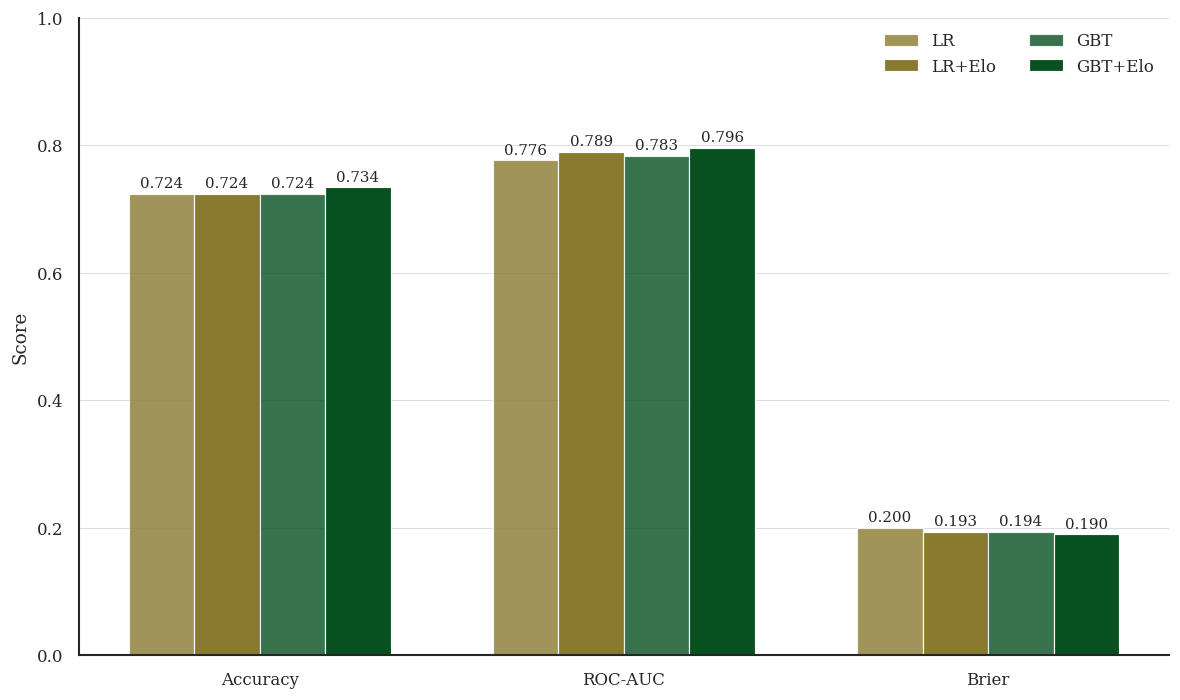

Saved: model_comparison.pdf


In [135]:
metrics = [('acc','Accuracy'),('auc','ROC-AUC'),('brier','Brier')]
configs  = [
    ('LR',      SECONDARY, 0.8, results['no_elo']['lr'][2]),
    ('LR+Elo',  SECONDARY, 1.0, results['with_elo']['lr'][2]),
    ('GBT',     PRIMARY,   0.8, results['no_elo']['xgb'][2]),
    ('GBT+Elo', PRIMARY,   1.0, results['with_elo']['xgb'][2]),
]
x, w = np.arange(len(metrics)), 0.18
 
fig, ax = plt.subplots()
 
for i, (lbl, col, alpha, m) in enumerate(configs):
    vals = [m[k] for k,_ in metrics]
    bars = ax.bar(x+(i-1.5)*w, vals, w, label=lbl,
                  color=col, alpha=alpha, edgecolor='white', lw=0.7)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f'{v:.3f}', ha='center', fontsize=9)
 
ax.set(ylabel='Score', ylim=(0,1))
ax.set_xticks(x)
ax.set_xticklabels([n for _,n in metrics])
ax.legend(ncol=2)
 
gridlines_horizontal_only()
 
plt.tight_layout()
save_fig('model_comparison.pdf')

Computing bootstrap CIs (n=1000)...
  LR: AUC=0.776
  GBT: AUC=0.783
  LR+Elo: AUC=0.789
  GBT+Elo: AUC=0.796
✓ Gridlines: Subtle (horizontal only)


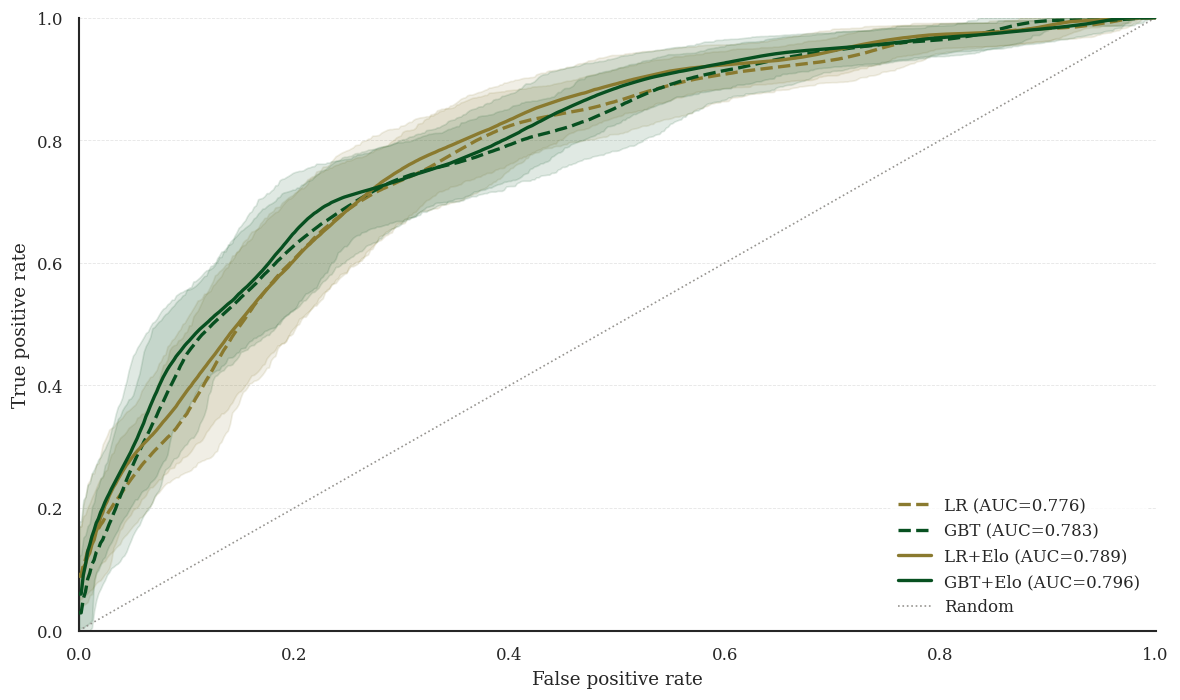

Saved: model_roc_curves.pdf


In [136]:
FPR_GRID = np.linspace(0, 1, 500)
rng      = np.random.default_rng(SEED)
 
def bootstrap_roc(y_true, y_score, n=1000):
    tprs = []
    for _ in range(n):
        idx = rng.integers(0, len(y_true), len(y_true))
        yt, ys = np.array(y_true)[idx], np.array(y_score)[idx]
        if len(np.unique(yt)) < 2: continue
        fpr_b, tpr_b, _ = roc_curve(yt, ys)
        tprs.append(np.interp(FPR_GRID, fpr_b, tpr_b))
    t = np.array(tprs)
    return t.mean(0), np.quantile(t,0.025,0), np.quantile(t,0.975,0)
 
curve_specs = [
    ('LR',      SECONDARY,'--',results['no_elo']['lr'][1]),
    ('GBT',     PRIMARY,  '--',results['no_elo']['xgb'][1]),
    ('LR+Elo',  SECONDARY,'-', results['with_elo']['lr'][1]),
    ('GBT+Elo', PRIMARY,  '-', results['with_elo']['xgb'][1]),
]
 
curves = []
print('Computing bootstrap CIs (n=1000)...')
for lbl, col, ls, prob in curve_specs:
    fpr, tpr, _ = roc_curve(y_te, prob)
    auc_value = roc_auc_score(y_te, prob)
    mean, lo, hi = bootstrap_roc(y_te, prob)
    curves.append((lbl, col, ls, auc_value, mean, lo, hi))
    print(f'  {lbl}: AUC={auc_value:.3f}')
 
fig, ax = plt.subplots()
 
for lbl, col, ls, auc_val, mean, lo, hi in curves:
    ax.plot(FPR_GRID, mean, color=col, lw=2, ls=ls, zorder=3,
            label=f'{lbl} (AUC={auc_val:.3f})')
    ax.fill_between(FPR_GRID, lo, hi, color=col, alpha=0.12, zorder=2)
 
ax.plot([0,1],[0,1], color=GREY, lw=1, ls=':', label='Random')
ax.set(xlim=(0,1), ylim=(0,1),
       xlabel='False positive rate', ylabel='True positive rate')
 
ax.legend(loc='lower right', frameon=True, facecolor='white', edgecolor='white')

gridlines_subtle()
 
plt.tight_layout()
save_fig('model_roc_curves.pdf')

✓ Gridlines: Subtle (horizontal only)


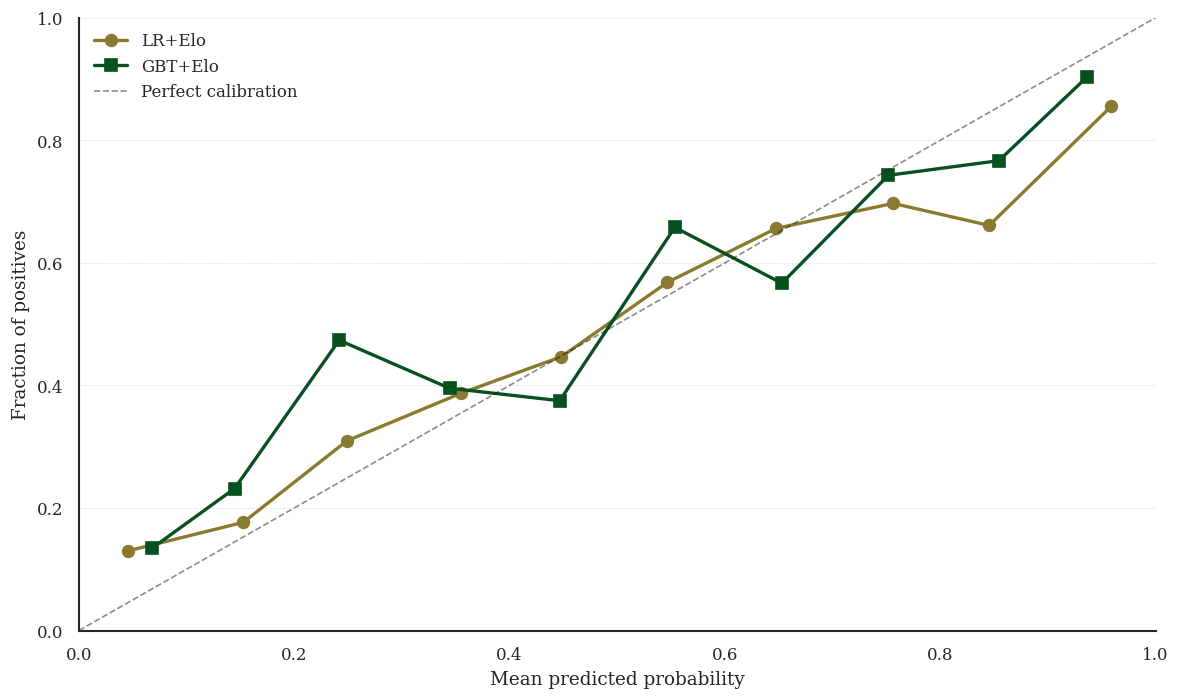

Saved: model_calibration.pdf


In [137]:
fig, ax = plt.subplots()
 
for lbl, col, marker, prob in [
    ('LR+Elo',  SECONDARY, 'o', results['with_elo']['lr'][1]),
    ('GBT+Elo', PRIMARY,   's', results['with_elo']['xgb'][1]),
]:
    pt, pp = calibration_curve(y_te, prob, n_bins=10, strategy='uniform')
    ax.plot(pp, pt, marker=marker, ms=7, color=col, lw=2, label=lbl)
 
ax.plot([0,1],[0,1], 'k--', lw=1, alpha=0.5, label='Perfect calibration')
ax.set(xlabel='Mean predicted probability', ylabel='Fraction of positives',
       xlim=(0,1), ylim=(0,1))
 
ax.legend()
gridlines_subtle() 
plt.tight_layout()
save_fig('model_calibration.pdf')

In [138]:
def expected_calibration_error(y_true, y_proba, n_bins=10):
    bins = np.linspace(0, 1, n_bins+1)
    ece = 0
    for i in range(len(bins)-1):
        mask = (y_proba >= bins[i]) & (y_proba < bins[i+1])
        if mask.sum() > 0:
            acc = (y_true[mask] == 1).mean()
            conf = y_proba[mask].mean()
            ece += np.abs(acc - conf) * mask.sum() / len(y_true)
    return ece

ece_val = expected_calibration_error(y_te, gbt_proba)
print(f"Expected Calibration Error: {ece_val:.4f}")

Expected Calibration Error: 0.0808


## Permutation Feature Importance

Beyond tree-based impurity scores, permutation importance measures predictive contribution by shuffling each feature and observing performance degradation. More model-agnostic and robust to feature correlations.

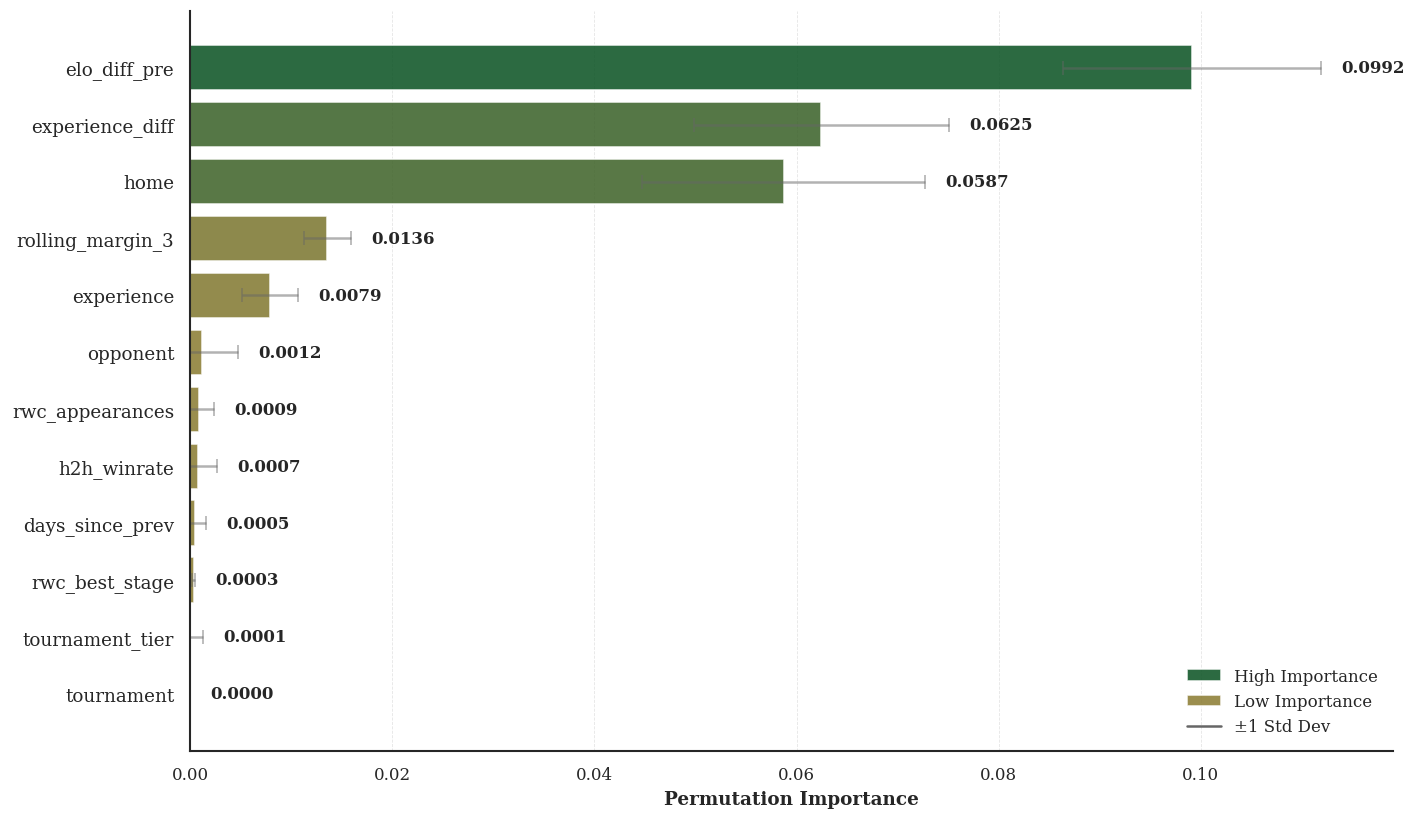

Saved: model_feature_importance.pdf

✓ Saved: model_feature_importance.pdf


In [149]:
# ── Permutation Feature Importance — GRADIENT VERSION ───────────────

fig, ax = plt.subplots(figsize=(12, 7))

top_12 = perm_df.head(12)
y_pos = np.arange(len(top_12))

# Create gradient colormap:
from matplotlib.colors import LinearSegmentedColormap
gradient_cmap = LinearSegmentedColormap.from_list('gradient', [SECONDARY, PRIMARY])

# Normalize importance to [0, 1] for color mapping
norm = plt.Normalize(vmin=top_12['Importance_Mean'].min(), 
                     vmax=top_12['Importance_Mean'].max())
colors = [gradient_cmap(norm(val)) for val in top_12['Importance_Mean'].values]

# Clean bars with error bars
bars = ax.barh(y_pos, top_12['Importance_Mean'].values, 
               xerr=top_12['Importance_Std'].values,
               color=colors, alpha=0.85, edgecolor='white', lw=1,
               error_kw={'elinewidth': 1.5, 'capsize': 4, 'alpha': 0.5, 'ecolor': '#666'})

# Value labels outside
for i, (idx, row) in enumerate(top_12.iterrows()):
    value = row['Importance_Mean']
    error = row['Importance_Std']
    ax.text(value + error + 0.002, i, f'{value:.4f}', 
            va='center', fontsize=10, weight='bold')

# Clean formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(top_12['Feature'].values, fontsize=11)
ax.set_xlabel('Permutation Importance', fontsize=11, weight='bold')
ax.set_xlim(0, top_12['Importance_Mean'].max() * 1.2)

# Subtle gridlines
ax.grid(axis='x', linestyle='--', alpha=0.2, linewidth=0.5)
ax.set_axisbelow(True)

ax.invert_yaxis()

# SIMPLE LEGEND
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=PRIMARY, alpha=0.85, label='High Importance'),
    Patch(facecolor=SECONDARY, alpha=0.85, label='Low Importance'),
    plt.Line2D([0], [0], color='#666', lw=1.5, label='±1 Std Dev')
]
ax.legend(handles=legend_elements, loc='lower right', frameon=False, fontsize=10)

plt.tight_layout()
save_fig('model_feature_importance.pdf')
print('\n✓ Saved: model_feature_importance.pdf')